# Procesamiento de datos
Dada la completación de la limpieza de datos de la etapa pasada que nos asegura la transferibilidad de las imagenes originles con las labeled en terminos del posicionamiento del recuadro de logo, se procede con la generacion de las metricas de Bounding Boxes en el formato YOLO para el entrenamiento del modelo.

In [23]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import shutil
import random
import yaml

In [24]:
DATA_DIRS = {
    "bottles": Path("./data/clean/bottles"),
    "tshirts":  Path("./data/clean/tshirts"),
}

SAMPLES_OUTPUT = Path("./data/output/pipeline_samples")
SAMPLES_OUTPUT.mkdir(parents=True, exist_ok=True)

## 1. Limitaciones
Aunque la informacion de ambas imagenes sea transferible, nos enfrentamos frente una limitación a la hora de la extracción de la mascara del recuadro verde: la compresión JPG.

La compresión JPG puede introducir variabilidad en los valores concretos de los pixeles que pertenecen al area del logo. Esto significa que utilizar una mascara global para la extracción de estas areas a partir del valor del color objetivo `#c0f0b4 ` introduciria ruido que puede limitar este proceso.

La solución a esta limitación viene en dos partes:
- HSV como encoder de color:
El encoding de color HSV, en comparación con el estandar RGB, se presta mas al uso de rangos para comparar colores que son cercanos. Es decir, nos permiten la implementación de un rango mas menos riesgos para la detección del area del logo.
- Morfología de contracción y dilatación
Asimismo, si en algun caso ruido o en productos verdes, zonas de color similar, llegan a impedir la detección del area concreta del logo, se decide aplicar dos etapas de morfología que nos permiten alterar la mascara que nos llevará a los limitesde la bounding box.
La primera es una morfología de contracción, que nos ayuda a eliminar las zonas pequeñas derivadas del ruido, y una subsecuente etapa de dilatación para recuperar el espacio perdido en el paso pasado y compensar por el borde (color verde oscuro) del recuadro de logo original.

In [25]:
# Rango HSV para #c0f0b4
# OpenCV HSV: H≈54, S≈64, V≈240
HSV_LOWER = np.array([44,  20, 170])
HSV_UPPER = np.array([65, 120, 255])

# Contracción:
CLOSE_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
CLOSE_ITER = 2

# Dilatación
OPEN_KERNEL  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
OPEN_ITER = 1

# Limite de contorno de area
MIN_CONTOUR_AREA = 500

# Samples
N_SAMPLES = 1

## 2. Aplicación

In [26]:
# Parejas validas en directorio clean
pairs = []
for class_name, directory in DATA_DIRS.items():
    all_stems = {f.stem: f for f in directory.glob("*.jpg")}
    originals = {s: p for s, p in all_stems.items() if not s.endswith("-labeled")}
    labeled   = {s.replace("-labeled", ""): p for s, p in all_stems.items() if s.endswith("-labeled")}

    for img_id, orig_path in sorted(originals.items()):
        if img_id in labeled:
            pairs.append({
                "class":      class_name,
                "id":         img_id,
                "orig_path":  orig_path,
                "label_path": labeled[img_id],
            })

print(f"Parejas identificadas: {len(pairs)}")
pd.DataFrame(pairs).groupby("class")["id"].count()



Parejas identificadas: 247


class
bottles    161
tshirts     86
Name: id, dtype: int64

In [27]:
# Ejemplos
samples = []
for class_name in DATA_DIRS:
    class_pairs = [p for p in pairs if p["class"] == class_name]
    samples.extend(class_pairs[:N_SAMPLES])

sample_ids = {s["id"] for s in samples}
print("Samples:", [s["id"] for s in samples])


Samples: ['image-0026', 'image-0195']


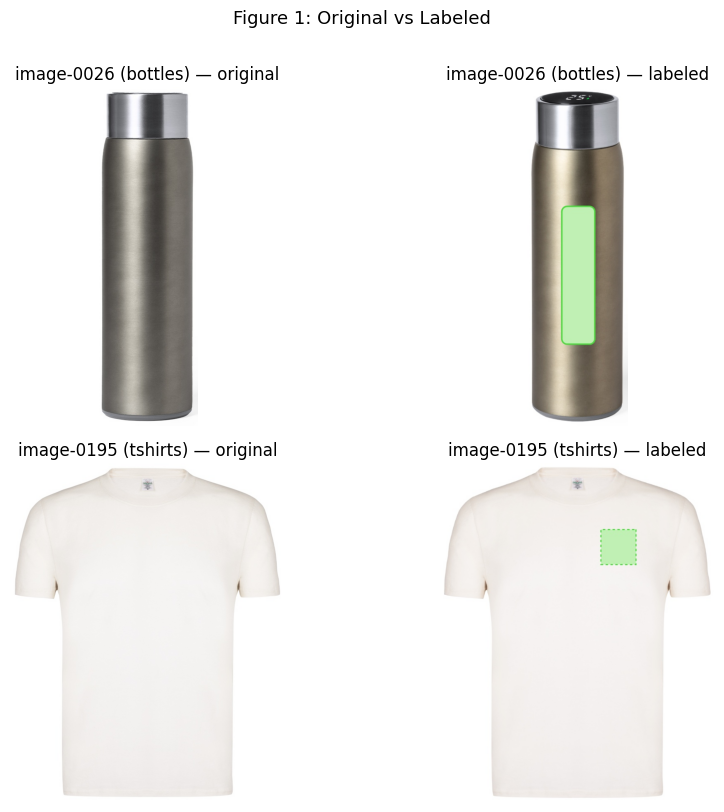

In [28]:
# Showcase
n = len(samples)
fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
if n == 1:
    axes = [axes]

for i, s in enumerate(samples):
    orig  = cv2.cvtColor(cv2.imread(str(s["orig_path"])),  cv2.COLOR_BGR2RGB)
    label = cv2.cvtColor(cv2.imread(str(s["label_path"])), cv2.COLOR_BGR2RGB)
    axes[i][0].imshow(orig);  axes[i][0].set_title(f"{s['id']} ({s['class']}) — original"); axes[i][0].axis("off")
    axes[i][1].imshow(label); axes[i][1].set_title(f"{s['id']} ({s['class']}) — labeled");  axes[i][1].axis("off")

plt.suptitle("Figure 1: Original vs Labeled", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [44]:
# Pipeline completa - Showcase
results = []
for p in pairs:
    label_bgr = cv2.imread(str(p["label_path"]))
    orig_bgr = cv2.imread(str(p["orig_path"]))

    label_h, label_w = label_bgr.shape[:2]
    orig_h, orig_w = orig_bgr.shape[:2]

    # 1) Conversion HSV y mascara
    hsv = cv2.cvtColor(label_bgr, cv2.COLOR_BGR2HSV)
    mask_raw = cv2.inRange(hsv, HSV_LOWER, HSV_UPPER)

    # 2) Morfología de contracción
    mask_closed = cv2.morphologyEx(mask_raw, cv2.MORPH_CLOSE, CLOSE_KERNEL, iterations=CLOSE_ITER)

    # 3) Morfología de dilatación
    mask_opened = cv2.morphologyEx(mask_closed, cv2.MORPH_OPEN, OPEN_KERNEL, iterations=OPEN_ITER)

    # 4) Limite de contorno
    contours, _ = cv2.findContours(mask_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) >= MIN_CONTOUR_AREA]


    if not contours:
        continue

    largest = max(contours, key=cv2.contourArea)
    bx, by, bw, bh = cv2.boundingRect(largest)

    # 5) Escalar bounding box
    sx = orig_w / label_w
    sy = orig_h / label_h
    ox, oy, ow, oh = int(bx * sx), int(by * sy), int(bw * sx), int(bh * sy)

    # 6) Normalización de coordenadas YOLO
    x_center_n = (ox + ow / 2) / orig_w
    y_center_n = (oy + oh / 2) / orig_h
    w_n        = ow / orig_w
    h_n        = oh / orig_h
    

    # Save intermediate images for sample IDs only
    if p["id"] in sample_ids:
        base = SAMPLES_OUTPUT / p["id"]

        contour_vis = cv2.cvtColor(mask_opened.copy(), cv2.COLOR_GRAY2BGR)
        cv2.drawContours(contour_vis, [largest], -1, (0, 200, 0), 2)
        cv2.rectangle(contour_vis, (bx, by), (bx + bw, by + bh), (0, 0, 220), 2)

        cv2.imwrite(str(base) + "_1_mask_raw.png",  mask_raw)
        cv2.imwrite(str(base) + "_2_closed.png",    mask_closed)
        cv2.imwrite(str(base) + "_3_opened.png",    mask_opened)
        cv2.imwrite(str(base) + "_4_contour.png",   contour_vis)
    
    results.append({
        **p,
        "bbox_lx": bx, "bbox_ly": by, "bbox_lw": bw, "bbox_lh": bh,
        "bbox_ox": ox, "bbox_oy": oy, "bbox_ow": ow, "bbox_oh": oh,
        "x_center_n": round(x_center_n, 6),
        "y_center_n": round(y_center_n, 6),
        "w_n": round(w_n, 6),
        "h_n": round(h_n, 6),
    })

df = pd.DataFrame(results)

print(f"Procesadas: {len(df)}")



Procesadas: 247


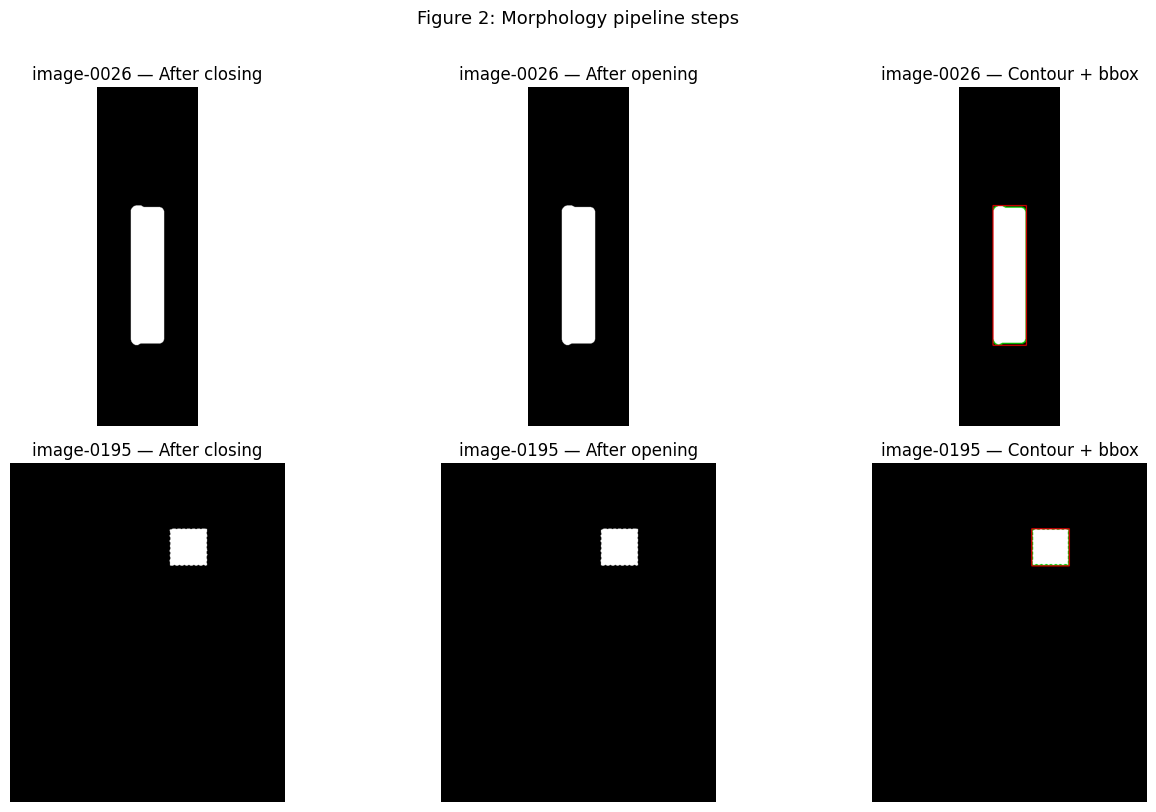

In [45]:

sample_rows = df[df["id"].isin(sample_ids)].reset_index(drop=True)
n = len(sample_rows)

fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]

col_titles = ["After closing", "After opening", "Contour + bbox"]

for i, row in sample_rows.iterrows():
    base    = str(SAMPLES_OUTPUT / row["id"])
    closed  = cv2.imread(base + "_2_closed.png",  cv2.IMREAD_GRAYSCALE)
    opened  = cv2.imread(base + "_3_opened.png",  cv2.IMREAD_GRAYSCALE)
    contour = cv2.cvtColor(cv2.imread(base + "_4_contour.png"), cv2.COLOR_BGR2RGB)

    for ax, img, title in zip(axes[i], [closed, opened, contour], col_titles):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{row['id']} — {title}")
        ax.axis("off")

plt.suptitle("Figure 2: Morphology pipeline steps", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

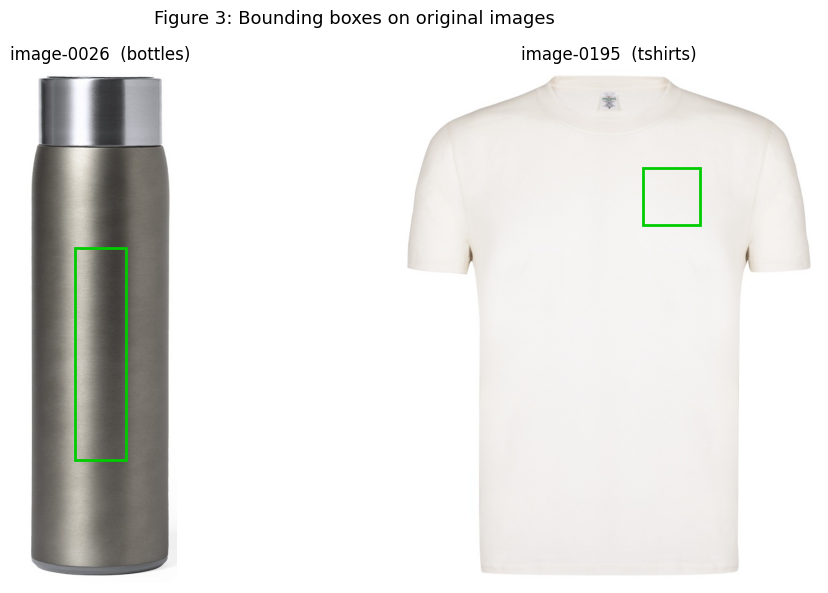

In [46]:

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    orig = cv2.cvtColor(cv2.imread(str(row["orig_path"])), cv2.COLOR_BGR2RGB)
    ax.imshow(orig)
    rect = patches.Rectangle(
        (row["bbox_ox"], row["bbox_oy"]), row["bbox_ow"], row["bbox_oh"],
        linewidth=2, edgecolor="#00cc00", facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(f"{row['id']}  ({row['class']})")
    ax.axis("off")

plt.suptitle("Figure 3: Bounding boxes on original images", fontsize=13)
plt.tight_layout()
plt.show()

In [47]:

display_cols = ["class", "id", "bbox_ox", "bbox_oy", "bbox_ow", "bbox_oh",
                "x_center_n", "y_center_n", "w_n", "h_n"]
print(df[display_cols].head(10).to_string(index=False))


  class         id  bbox_ox  bbox_oy  bbox_ow  bbox_oh  x_center_n  y_center_n      w_n      h_n
bottles image-0026       85      300       84      354    0.500000    0.555297 0.330709 0.412107
bottles image-0028       73      242       80      298    0.535545    0.572474 0.379147 0.436310
bottles image-0030      117      319       75      311    0.520202    0.548555 0.252525 0.359538
bottles image-0031       82      607       97       95    0.526210    0.792373 0.391129 0.115012
bottles image-0032       59      337      144      160    0.524000    0.504843 0.576000 0.193705
bottles image-0095       85      305      109      411    0.385359    0.580774 0.301105 0.467577
bottles image-0162       90      320      110      345    0.494881    0.540022 0.375427 0.378289
bottles image-0163      183      380       41      295    0.810757    0.603547 0.163347 0.337529
bottles image-0164      117      357       66      249    0.545455    0.623705 0.240000 0.322539
bottles image-0166       35   

# 4. Generación de Dataset YOLO

Los dataset para modelos YOLO tienen una estructura distintiva, donde las imagenes y labels estan separadas por folders y, en nuestro caso donde tenemos diferentes clases como botellas y tshirts, YOLO necesita estos dos en el mismo directorio. Asimismo, requiere de un archivo en format `yaml` como directorio.

In [48]:
# Guardar CSV
df.to_csv("pipeline_results.csv", index=False)
print(f"Saved pipeline_results.csv  ({len(df)} rows)")

Saved pipeline_results.csv  (247 rows)


In [49]:
CLASS_ID = {"bottles": 0, "tshirts": 1}

# Se considera un 20% de particion para validación
VAL_SPLIT = 0.2 
SEED      = 67 # 67

PIPELINE_CSV  = Path("pipeline_results.csv")
CLEAN_DIRS    = {"bottles": Path("./data/clean/bottles"), "tshirts": Path("./data/clean/tshirts")}
DATASET_ROOT  = Path("../dataset")

In [50]:

df = pd.read_csv(PIPELINE_CSV)

total    = len(df)
df_clean = df.copy().reset_index(drop=True)

print(f"Entradas totales : {total}")
df_clean.groupby("class")["id"].count()

Entradas totales : 247


class
bottles    161
tshirts     86
Name: id, dtype: int64

In [51]:
# Semilla para particion
random.seed(SEED)
train_rows, val_rows = [], []

# Particion test/val manual
for class_name, group in df_clean.groupby("class"):
    ids = group["id"].tolist()
    random.shuffle(ids)

    n_val   = max(1, round(len(ids) * VAL_SPLIT))
    val_ids = set(ids[:n_val])

    train_rows.append(group[~group["id"].isin(val_ids)])
    val_rows.append(group[ group["id"].isin(val_ids)])

df_train = pd.concat(train_rows).reset_index(drop=True)
df_val   = pd.concat(val_rows).reset_index(drop=True)

print(f"Train: {len(df_train)}  ({df_train.groupby('class')['id'].count().to_dict()})")
print(f"Val  : {len(df_val)}    ({df_val.groupby('class')['id'].count().to_dict()})")


Train: 198  ({'bottles': 129, 'tshirts': 69})
Val  : 49    ({'bottles': 32, 'tshirts': 17})


In [52]:
for split in ("train", "val"):
    (DATASET_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)
print("Estructura de folder creada.")


Estructura de folder creada.


In [53]:
# Guardar imagenes en la erstructura de folder
def write_split(df_split, split_name):
    img_dir   = DATASET_ROOT / "images" / split_name
    label_dir = DATASET_ROOT / "labels" / split_name
    skipped   = []

    for _, row in df_split.iterrows():
        src_img = CLEAN_DIRS[row["class"]] / (row["id"] + ".jpg")

        if not src_img.exists():
            skipped.append(row["id"])
            continue

        # Co[iar imagenes sin prefijos de clases. Tampoco es necesario pues TSHIRTS y botellas
        # Tienen ids que no se sobrelapan
        dst_img = img_dir / (row["id"] + ".jpg")
        shutil.copy2(src_img, dst_img)

        # YOLO txt
        class_id = CLASS_ID[row["class"]]
        label_line = f"{class_id} {row['x_center_n']} {row['y_center_n']} {row['w_n']} {row['h_n']}\n"

        dst_txt = label_dir / (row["id"] + ".txt")
        dst_txt.write_text(label_line)

    return skipped

skipped_train = write_split(df_train, "train")
skipped_val   = write_split(df_val,   "val")

print(f"Train escritos: {len(df_train) - len(skipped_train)}  saltados: {len(skipped_train)}")
print(f"Val   escritos: {len(df_val)   - len(skipped_val)}    saltados: {len(skipped_val)}")

if skipped_train or skipped_val:
    print("IDs saltadas (imagen no encontrada en data/clean/):", skipped_train + skipped_val)


Train escritos: 198  saltados: 0
Val   escritos: 49    saltados: 0


In [54]:
# Rediaccion del YAML
data_yaml = {
    "path":  str(DATASET_ROOT.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(CLASS_ID),
    "names": [name for name, _ in sorted(CLASS_ID.items(), key=lambda x: x[1])],
}

yaml_path = DATASET_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"YAML escrito: {yaml_path}")
print(yaml_path.read_text())


YAML escrito: ..\dataset\data.yaml
path: C:\Users\JM\Documents\5to1sem\Vision\proyecto_vision\dataset
train: images/train
val: images/val
nc: 2
names:
- bottles
- tshirts



In [55]:
# Showcase
for split in ("train", "val"):
    imgs   = list((DATASET_ROOT / "images" / split).glob("*.jpg"))
    labels = list((DATASET_ROOT / "labels" / split).glob("*.txt"))
    print(f"{split:5s}  images: {len(imgs):4d}  labels: {len(labels):4d}  match: {len(imgs) == len(labels)}")

print("\nArchivos de Label ejemplos")
for txt in sorted((DATASET_ROOT / "labels" / "train").glob("*.txt"))[:5]:
    print(f"  {txt.name}: {txt.read_text().strip()}")


train  images:  198  labels:  198  match: True
val    images:   49  labels:   49  match: True

Archivos de Label ejemplos
  image-0026.txt: 0 0.5 0.555297 0.330709 0.412107
  image-0028.txt: 0 0.535545 0.572474 0.379147 0.43631
  image-0030.txt: 0 0.520202 0.548555 0.252525 0.359538
  image-0031.txt: 0 0.52621 0.792373 0.391129 0.115012
  image-0032.txt: 0 0.524 0.504843 0.576 0.193705
